### Architecture
In this experiment swin tranformer model is taken and applied on images with final head removal and single pawpularity output is added. In addition, strong resolution with strong augmentation is added, and MSELoss is added 

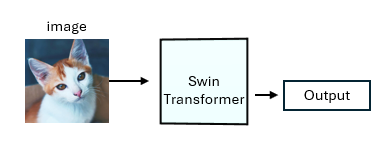

### Analysis
Swin models see the image as a set of tokens and uses multi‑head self‑attention to capture long‑range dependencies and global layout (how the pet, background, and other objects relate across the whole frame), whereas EfficientNet relies on local convolutions and pooling, which are less expressive for scene‑level images 


In [19]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [20]:
import os
import sys
sys.path.insert(0, os.path.abspath("../.."))

In [21]:
import os
import sys
import math
import random
from pathlib import Path

import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image

import torch

In [22]:
main_folder = "../.."
sys.path.insert(0, os.path.join(main_folder))

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("device:", device)

device: cuda


In [23]:
from src.config import EXP_CONFIGS
from src.swin_cam import (
    cam_for_single_fold,
    cam_for_single_fold_aux,
    ensemble_cam_across_folds,
    show_cam_triplet,
    unnormalize_to_numpy,
    overlay_cam_on_image,
)

In [24]:
# -----------------------------
# Update these paths as needed
# -----------------------------
IMG_FOLDER = os.path.join(main_folder, "data", "train")

# Must contain:
# Id, Pawpularity, visibility_ratio, yolo_conf, bbox_x1, bbox_y1, bbox_x2, bbox_y2
PSEUDO_CSV = os.path.join(main_folder, "data", "train_with_visibility_test.csv")

EXP3_OUT = os.path.join(main_folder, "outputs", "extra", "exp3_swin_384_strong_MSE")
EXP15_OUT = os.path.join(main_folder, "outputs", "extra", "exp15_swin_384_strong_MSE_aux_brisque_normalized")

# change this to your real exp15b output folder
EXP15B_OUT = os.path.join(main_folder, "outputs", "extra", "exp15_swin_384_strong_MSE_aux_visibility_normalized")

YOLO_CONF_THRESH = 0.30
FOLD = 1
N_QUAL = 6
N_EVAL = 200

In [25]:
required_cols = [
    "Id", "Pawpularity",
    "visibility_ratio", "yolo_conf",
    "bbox_x1", "bbox_y1", "bbox_x2", "bbox_y2",
]

pseudo_df = pd.read_csv(PSEUDO_CSV)

missing_cols = [c for c in required_cols if c not in pseudo_df.columns]
if missing_cols:
    raise ValueError(
        f"Pseudo CSV is missing required columns: {missing_cols}\n"
        f"Current columns are: {pseudo_df.columns.tolist()}"
    )

print("Loaded:", PSEUDO_CSV)
print("Rows:", len(pseudo_df))
pseudo_df.head()

Loaded: ../../data/train_with_visibility_test.csv
Rows: 9912


,Id,Subject Focus,Eyes,Face,Near,Action,Accessory,Group,Collage,Human,...,Info,Blur,Pawpularity,BRISQUE,visibility_ratio,yolo_conf,bbox_x1,bbox_y1,bbox_x2,bbox_y2
0,0007de18844b0dbbb5e1f607da0606e0,0,1,1,1,0,0,1,0,0,...,0,0,63,10.718445,0.253116,0.917594,121.863953,113.367577,325.820984,475.250153
1,0009c66b9439883ba2750fb825e1d7db,0,1,1,0,0,0,0,0,0,...,0,0,42,27.012390,0.085597,0.872381,648.318298,199.980301,895.027710,477.115906
2,0013fd999caf9a3efe1352ca1b0d937e,0,1,1,1,0,0,0,0,1,...,0,0,28,36.096863,0.502442,0.632847,28.592377,55.131546,578.273071,686.930298
3,0018df346ac9c1d8413cfcc888ca8246,0,1,1,1,0,0,0,0,0,...,0,0,15,13.769714,0.471357,0.923749,0.000000,219.714081,402.850403,560.901733
4,001dc955e10590d3ca4673f034feeef2,0,0,0,1,0,0,1,0,0,...,0,0,72,-0.058411,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000


In [26]:
cfg3 = EXP_CONFIGS["exp3"].copy()
cfg3["img_size"] = 384
cfg3["loss"] = "mse"

cfg15 = EXP_CONFIGS["exp15_aux_brisque"].copy()
cfg15["img_size"] = 384
cfg15["loss"] = "mse"

# Manual fallback if exp15b is not in EXP_CONFIGS
cfg15b = EXP_CONFIGS["exp15_aux_brisque"].copy()
cfg15b["img_size"] = 384
cfg15b["name"]     = "exp15_swin_384_strong_MSE_aux_visibility_normalized"
cfg15b["loss"]     = "mse"

cfg15b["aux_tasks"] = ["visibility_ratio"]
cfg15b["aux_loss_weights"] = {"visibility_ratio": 0.1} 

print("exp3:", cfg3)
print("exp15:", cfg15)
print("exp15b:", cfg15b)

exp3: {'n_splits': 5, 'seed': 42, 'epochs': 10, 'patience': 5, 'lr': 2e-05, 'weight_decay': 0.01, 'aux_tasks': [], 'aux_loss_weights': {}, 'name': 'Exp3_SwinT_384_Strong', 'backbone': 'swin_large_patch4_window12_384', 'img_size': 384, 'aug': 'strong', 'loss': 'mse', 'batch_size': 12}
exp15: {'n_splits': 5, 'seed': 42, 'epochs': 10, 'patience': 5, 'lr': 2e-05, 'weight_decay': 0.01, 'aux_tasks': ['brisque'], 'aux_loss_weights': {'brisque': 0.1}, 'name': 'Exp15_SwinT_384_Strong_AuxBRISQUE', 'backbone': 'swin_large_patch4_window12_384', 'img_size': 384, 'aug': 'strong', 'loss': 'mse', 'batch_size': 12}
exp15b: {'n_splits': 5, 'seed': 42, 'epochs': 10, 'patience': 5, 'lr': 2e-05, 'weight_decay': 0.01, 'aux_tasks': ['visibility_ratio'], 'aux_loss_weights': {'visibility_ratio': 0.1}, 'name': 'exp15_swin_384_strong_MSE_aux_visibility_normalized', 'backbone': 'swin_large_patch4_window12_384', 'img_size': 384, 'aug': 'strong', 'loss': 'mse', 'batch_size': 12}


In [27]:
def make_bbox_mask(h, w, x1, y1, x2, y2):
    mask = np.zeros((h, w), dtype=np.float32)

    x1 = int(round(max(0, min(w, x1))))
    x2 = int(round(max(0, min(w, x2))))
    y1 = int(round(max(0, min(h, y1))))
    y2 = int(round(max(0, min(h, y2))))

    if x2 <= x1 or y2 <= y1:
        return mask

    mask[y1:y2, x1:x2] = 1.0
    return mask


def make_face_proxy_mask(h, w, x1, y1, x2, y2):
    """
    Proxy face region from the pet bbox.
    Upper-central area of the bbox.
    """
    bw = x2 - x1
    bh = y2 - y1
    if bw <= 0 or bh <= 0:
        return np.zeros((h, w), dtype=np.float32)

    fx1 = x1 + 0.20 * bw
    fx2 = x1 + 0.80 * bw
    fy1 = y1 + 0.00 * bh
    fy2 = y1 + 0.45 * bh
    return make_bbox_mask(h, w, fx1, fy1, fx2, fy2)

In [28]:
def overlap_mean_inside_mask(cam, mask, eps=1e-8):
    return float((cam * mask).sum() / (mask.sum() + eps))


def overlap_fraction_of_cam_mass(cam, mask, eps=1e-8):
    return float((cam * mask).sum() / (cam.sum() + eps))

In [29]:
def get_image_and_row(img_id, df):
    row = df[df["Id"] == img_id].iloc[0]
    img_path = os.path.join(IMG_FOLDER, img_id + ".jpg")
    img_pil = Image.open(img_path).convert("RGB")
    return img_pil, row


def get_main_cam_exp3(img_pil, fold=1):
    ckpt = os.path.join(EXP3_OUT, f"model_fold{fold}.pt")
    cam, input_tensor, _ = cam_for_single_fold(
        img_pil=img_pil,
        ckpt_path=ckpt,
        backbone_name=cfg3["backbone"],
        img_size=cfg3["img_size"],
        device=device,
    )
    return cam, input_tensor


def get_main_cam_exp15(img_pil, fold=1):
    ckpt = os.path.join(EXP15_OUT, f"model_fold{fold}.pt")
    cam, input_tensor, _ = cam_for_single_fold_aux(
        img_pil=img_pil,
        ckpt_path=ckpt,
        backbone_name=cfg15["backbone"],
        img_size=cfg15["img_size"],
        aux_tasks=cfg15["aux_tasks"],
        head_name="main",
        device=device,
    )
    return cam, input_tensor


def get_aux_cam_exp15(img_pil, fold=1):
    ckpt = os.path.join(EXP15_OUT, f"model_fold{fold}.pt")
    cam, input_tensor, _ = cam_for_single_fold_aux(
        img_pil=img_pil,
        ckpt_path=ckpt,
        backbone_name=cfg15["backbone"],
        img_size=cfg15["img_size"],
        aux_tasks=cfg15["aux_tasks"],
        head_name="brisque",
        device=device,
    )
    return cam, input_tensor


def get_main_cam_exp15b(img_pil, fold=1):
    ckpt = os.path.join(EXP15B_OUT, f"model_fold{fold}.pt")
    cam, input_tensor, _ = cam_for_single_fold_aux(
        img_pil=img_pil,
        ckpt_path=ckpt,
        backbone_name=cfg15b["backbone"],
        img_size=cfg15b["img_size"],
        aux_tasks=cfg15b["aux_tasks"],
        head_name="main",
        device=device,
    )
    return cam, input_tensor


def get_aux_cam_exp15b(img_pil, fold=1):
    ckpt = os.path.join(EXP15B_OUT, f"model_fold{fold}.pt")
    cam, input_tensor, _ = cam_for_single_fold_aux(
        img_pil=img_pil,
        ckpt_path=ckpt,
        backbone_name=cfg15b["backbone"],
        img_size=cfg15b["img_size"],
        aux_tasks=cfg15b["aux_tasks"],
        head_name="visibility_ratio",
        device=device,
    )
    return cam, input_tensor

In [30]:
# def compute_cam_overlap_metrics(cam, img_pil, row):
#     w, h = img_pil.size

#     pet_mask = make_bbox_mask(
#         h, w,
#         row["bbox_x1"], row["bbox_y1"], row["bbox_x2"], row["bbox_y2"]
#     )
#     face_mask = make_face_proxy_mask(
#         h, w,
#         row["bbox_x1"], row["bbox_y1"], row["bbox_x2"], row["bbox_y2"]
#     )

#     metrics = {
#         "pet_overlap_mean": overlap_mean_inside_mask(cam, pet_mask),
#         "pet_overlap_mass": overlap_fraction_of_cam_mass(cam, pet_mask),
#         "face_overlap_mean": overlap_mean_inside_mask(cam, face_mask),
#         "face_overlap_mass": overlap_fraction_of_cam_mass(cam, face_mask),
#     }
#     return metrics, pet_mask, face_mask
def compute_cam_overlap_metrics(cam, img_pil, row):
    """
    cam: 2D numpy array (H_cam, W_cam), typically (384,384)
    img_pil: original PIL image (H_img, W_img)
    row: dataframe row with bbox_x1..bbox_y2 in original image coords

    We:
    - resize cam to (W_img, H_img)
    - build pet and face masks in original coords
    - compute overlap metrics in image space
    """
    W_img, H_img = img_pil.size  # PIL: (width, height)

    # 1) resize CAM to original image size
    cam_resized = cv2.resize(
        cam.astype(np.float32),
        (W_img, H_img),
        interpolation=cv2.INTER_LINEAR,
    )

    # 2) build masks in original image space
    pet_mask = make_bbox_mask(
        H_img, W_img,
        row["bbox_x1"], row["bbox_y1"], row["bbox_x2"], row["bbox_y2"]
    )
    face_mask = make_face_proxy_mask(
        H_img, W_img,
        row["bbox_x1"], row["bbox_y1"], row["bbox_x2"], row["bbox_y2"]
    )

    # 3) overlap metrics
    metrics = {
        "pet_overlap_mean": overlap_mean_inside_mask(cam_resized, pet_mask),
        "pet_overlap_mass": overlap_fraction_of_cam_mass(cam_resized, pet_mask),
        "face_overlap_mean": overlap_mean_inside_mask(cam_resized, face_mask),
        "face_overlap_mass": overlap_fraction_of_cam_mass(cam_resized, face_mask),
    }
    return metrics, pet_mask, face_mask


def read_oof_rmse(metrics_txt_path):
    if not os.path.exists(metrics_txt_path):
        return np.nan
    with open(metrics_txt_path, "r") as f:
        txt = f.read()
    for line in txt.splitlines():
        if line.startswith("OOF_RMSE:"):
            return float(line.split(":")[1].strip())
    return np.nan

In [31]:
valid_df = pseudo_df[pseudo_df["yolo_conf"] > YOLO_CONF_THRESH].copy().reset_index(drop=True)
print("Valid YOLO-detected images:", len(valid_df))
valid_df.head()

Valid YOLO-detected images: 9437


,Id,Subject Focus,Eyes,Face,Near,Action,Accessory,Group,Collage,Human,...,Info,Blur,Pawpularity,BRISQUE,visibility_ratio,yolo_conf,bbox_x1,bbox_y1,bbox_x2,bbox_y2
0,0007de18844b0dbbb5e1f607da0606e0,0,1,1,1,0,0,1,0,0,...,0,0,63,10.718445,0.253116,0.917594,121.863953,113.367577,325.820984,475.250153
1,0009c66b9439883ba2750fb825e1d7db,0,1,1,0,0,0,0,0,0,...,0,0,42,27.012390,0.085597,0.872381,648.318298,199.980301,895.027710,477.115906
2,0013fd999caf9a3efe1352ca1b0d937e,0,1,1,1,0,0,0,0,1,...,0,0,28,36.096863,0.502442,0.632847,28.592377,55.131546,578.273071,686.930298
3,0018df346ac9c1d8413cfcc888ca8246,0,1,1,1,0,0,0,0,0,...,0,0,15,13.769714,0.471357,0.923749,0.000000,219.714081,402.850403,560.901733
4,001dd4f6fafb890610b1635f967ea081,0,0,1,0,0,0,0,0,0,...,0,1,74,39.668640,0.078518,0.361735,182.824493,334.138550,378.360046,542.303589


In [32]:
exp3_oof_path = os.path.join(EXP3_OUT, "oof_detail.csv")
exp15_oof_path = os.path.join(EXP15_OUT, "oof_detail.csv")
exp15b_oof_path = os.path.join(EXP15B_OUT, "oof_detail.csv")

has_oof = all(os.path.exists(p) for p in [exp3_oof_path, exp15_oof_path, exp15b_oof_path])

if has_oof:
    exp3_oof = pd.read_csv(exp3_oof_path)
    exp15_oof = pd.read_csv(exp15_oof_path)
    exp15b_oof = pd.read_csv(exp15b_oof_path)

    common_ids = set(exp3_oof["Id"]) & set(exp15_oof["Id"]) & set(exp15b_oof["Id"])
    valid_df = valid_df[valid_df["Id"].isin(common_ids)].copy().reset_index(drop=True)
    print("After OOF intersection:", len(valid_df))
else:
    print("OOF files not all found. Continuing without OOF intersection.")

After OOF intersection: 9437


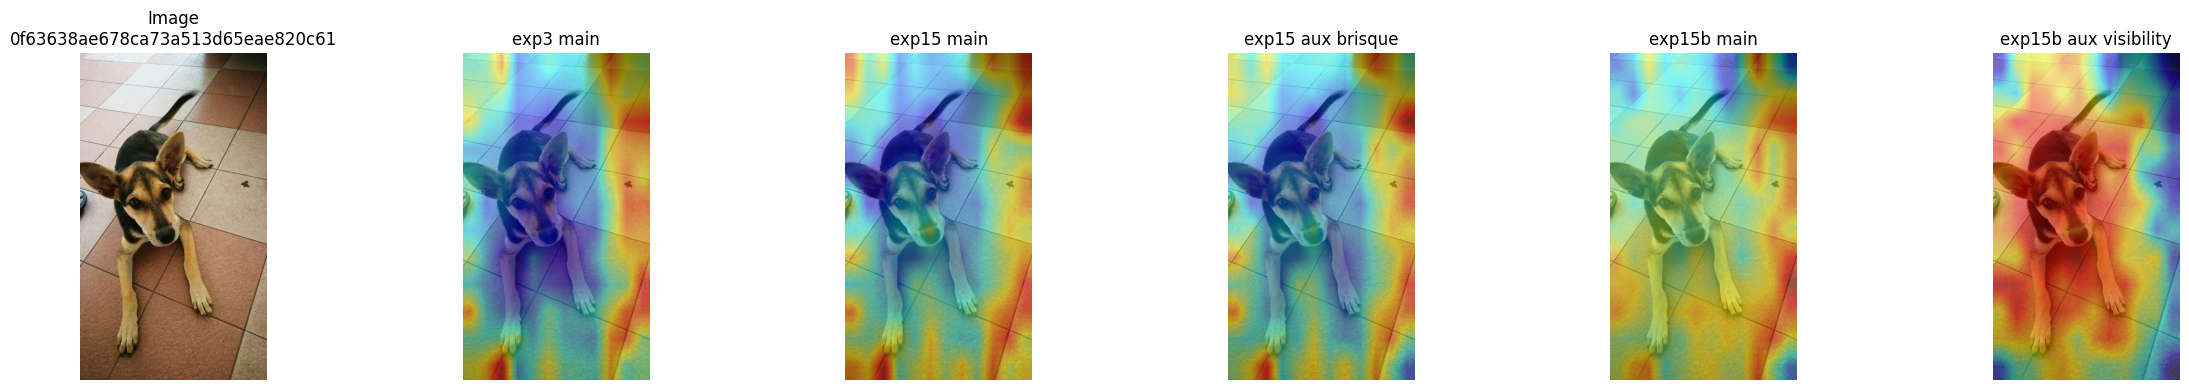

In [33]:
sample_row = valid_df.sample(1, random_state=42).iloc[0]
img_id = sample_row["Id"]

img_pil, row = get_image_and_row(img_id, valid_df)
rgb = np.array(img_pil.convert("RGB")).astype(np.float32) / 255.0

cam3, _ = get_main_cam_exp3(img_pil, fold=FOLD)
cam15_main, _ = get_main_cam_exp15(img_pil, fold=FOLD)
cam15_aux, _ = get_aux_cam_exp15(img_pil, fold=FOLD)

exp15b_available = os.path.exists(os.path.join(EXP15B_OUT, f"model_fold{FOLD}.pt"))
if exp15b_available:
    cam15b_main, _ = get_main_cam_exp15b(img_pil, fold=FOLD)
    cam15b_aux, _ = get_aux_cam_exp15b(img_pil, fold=FOLD)

pet_mask = make_bbox_mask(
    img_pil.size[1], img_pil.size[0],
    row["bbox_x1"], row["bbox_y1"], row["bbox_x2"], row["bbox_y2"]
)
face_mask = make_face_proxy_mask(
    img_pil.size[1], img_pil.size[0],
    row["bbox_x1"], row["bbox_y1"], row["bbox_x2"], row["bbox_y2"]
)

fig_cols = 6 if exp15b_available else 4
fig, axes = plt.subplots(1, fig_cols, figsize=(4 * fig_cols, 4))

axes[0].imshow(rgb)
axes[0].set_title(f"Image\n{img_id}")
axes[0].axis("off")

axes[1].imshow(overlay_cam_on_image(rgb, cam3))
axes[1].set_title("exp3 main")
axes[1].axis("off")

axes[2].imshow(overlay_cam_on_image(rgb, cam15_main))
axes[2].set_title("exp15 main")
axes[2].axis("off")

axes[3].imshow(overlay_cam_on_image(rgb, cam15_aux))
axes[3].set_title("exp15 aux brisque")
axes[3].axis("off")

if exp15b_available:
    axes[4].imshow(overlay_cam_on_image(rgb, cam15b_main))
    axes[4].set_title("exp15b main")
    axes[4].axis("off")

    axes[5].imshow(overlay_cam_on_image(rgb, cam15b_aux))
    axes[5].set_title("exp15b aux visibility")
    axes[5].axis("off")

plt.tight_layout()
plt.show()

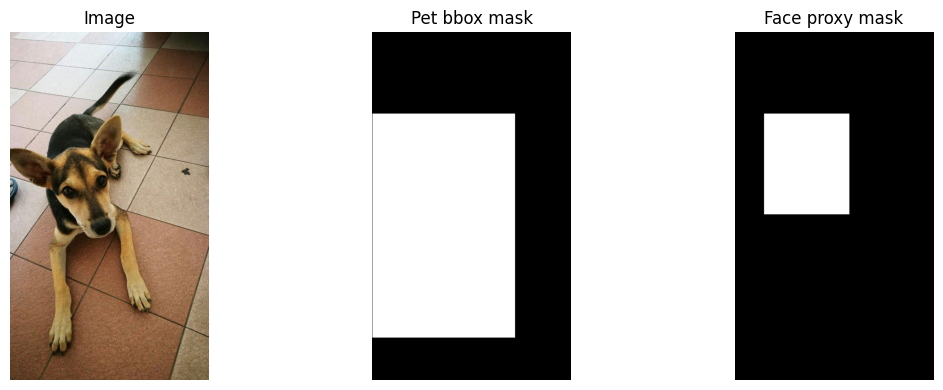

In [34]:
fig, axes = plt.subplots(1, 3, figsize=(12, 4))

axes[0].imshow(rgb)
axes[0].set_title("Image")

axes[1].imshow(pet_mask, cmap="gray")
axes[1].set_title("Pet bbox mask")

axes[2].imshow(face_mask, cmap="gray")
axes[2].set_title("Face proxy mask")

for ax in axes:
    ax.axis("off")

plt.tight_layout()
plt.show()

In [35]:
N_EVAL = min(N_EVAL, len(valid_df))
N_EVAL =2
eval_df = valid_df.sample(N_EVAL, random_state=42).reset_index(drop=True)
print("Evaluating:", len(eval_df))

rows = []

for i, r in eval_df.iterrows():
    img_id = r["Id"]

    try:
        img_pil, row = get_image_and_row(img_id, valid_df)

        # exp3 main
        cam3, _ = get_main_cam_exp3(img_pil, fold=FOLD)
        m3, _, _ = compute_cam_overlap_metrics(cam3, img_pil, row)
        rows.append({
            "Id": img_id,
            "model": "exp3_main",
            **m3,
        })

        # exp15 main
        cam15_main, _ = get_main_cam_exp15(img_pil, fold=FOLD)
        m15_main, _, _ = compute_cam_overlap_metrics(cam15_main, img_pil, row)
        rows.append({
            "Id": img_id,
            "model": "exp15_main",
            **m15_main,
        })

        # exp15 aux
        cam15_aux, _ = get_aux_cam_exp15(img_pil, fold=FOLD)
        m15_aux, _, _ = compute_cam_overlap_metrics(cam15_aux, img_pil, row)
        rows.append({
            "Id": img_id,
            "model": "exp15_aux_brisque",
            **m15_aux,
        })

        if exp15b_available:
            cam15b_main, _ = get_main_cam_exp15b(img_pil, fold=FOLD)
            m15b_main, _, _ = compute_cam_overlap_metrics(cam15b_main, img_pil, row)
            rows.append({
                "Id": img_id,
                "model": "exp15b_main",
                **m15b_main,
            })

            cam15b_aux, _ = get_aux_cam_exp15b(img_pil, fold=FOLD)
            m15b_aux, _, _ = compute_cam_overlap_metrics(cam15b_aux, img_pil, row)
            rows.append({
                "Id": img_id,
                "model": "exp15b_aux_visibility",
                **m15b_aux,
            })

    except Exception as e:
        print(f"Skipping {img_id} due to error: {e}")

metrics_df = pd.DataFrame(rows)
metrics_df.head()

Evaluating: 2


,Id,model,pet_overlap_mean,pet_overlap_mass,face_overlap_mean,face_overlap_mass
0,0f63638ae678ca73a513d65eae820c61,exp3_main,0.244790,0.288967,0.188021,0.059703
1,0f63638ae678ca73a513d65eae820c61,exp15_main,0.317805,0.344738,0.212679,0.062056
2,0f63638ae678ca73a513d65eae820c61,exp15_aux_brisque,0.318891,0.347778,0.233717,0.068562
3,0f63638ae678ca73a513d65eae820c61,exp15b_main,0.530233,0.455375,0.491765,0.113603
4,0f63638ae678ca73a513d65eae820c61,exp15b_aux_visibility,0.824043,0.592207,0.891123,0.172263


In [36]:
summary_df = metrics_df.groupby("model").agg({
    "pet_overlap_mean": ["mean", "std"],
    "pet_overlap_mass": ["mean", "std"],
    "face_overlap_mean": ["mean", "std"],
    "face_overlap_mass": ["mean", "std"],
}).round(4)

summary_df

pet_overlap_mean         pet_overlap_mass          \
                                  mean     std             mean     std   
model                                                                     
exp15_aux_brisque               0.2609  0.0820           0.2107  0.1938   
exp15_main                      0.2507  0.0949           0.2132  0.1860   
exp15b_aux_visibility           0.8064  0.0249           0.3905  0.2852   
exp15b_main                     0.5981  0.0959           0.2963  0.2249   
exp3_main                       0.2655  0.0293           0.1870  0.1442   

                      face_overlap_mean         face_overlap_mass          
                                   mean     std              mean     std  
model                                                                      
exp15_aux_brisque                0.1922  0.0587            0.0417  0.0380  
exp15_main                       0.1825  0.0427            0.0402  0.0309  
exp15b_aux_visibility            0.8493  0.0591            0.1122  0.0849  
exp15b_main                      0.6032  0.1576            0.0767  0.0522  
exp3_main                        0.2239  0.0507            0.0403  0.0275

In [37]:
summary_export = summary_df.copy()
summary_export.columns = ["_".join(col) for col in summary_export.columns]
summary_export = summary_export.reset_index()

rmse_rows = [
    {"model": "exp3_main", "oof_rmse": read_oof_rmse(os.path.join(EXP3_OUT, "metrics.txt"))},
    {"model": "exp15_main", "oof_rmse": read_oof_rmse(os.path.join(EXP15_OUT, "metrics.txt"))},
]

if exp15b_available:
    rmse_rows.append({
        "model": "exp15b_main",
        "oof_rmse": read_oof_rmse(os.path.join(EXP15B_OUT, "metrics.txt"))
    })

rmse_df = pd.DataFrame(rmse_rows)
final_table = summary_export.merge(rmse_df, on="model", how="left")
final_table

,model,pet_overlap_mean_mean,pet_overlap_mean_std,pet_overlap_mass_mean,pet_overlap_mass_std,face_overlap_mean_mean,face_overlap_mean_std,face_overlap_mass_mean,face_overlap_mass_std,oof_rmse
0,exp15_aux_brisque,0.2609,0.0820,0.2107,0.1938,0.1922,0.0587,0.0417,0.0380,NaN
1,exp15_main,0.2507,0.0949,0.2132,0.1860,0.1825,0.0427,0.0402,0.0309,18.1513
2,exp15b_aux_visibility,0.8064,0.0249,0.3905,0.2852,0.8493,0.0591,0.1122,0.0849,NaN
3,exp15b_main,0.5981,0.0959,0.2963,0.2249,0.6032,0.1576,0.0767,0.0522,18.1869
4,exp3_main,0.2655,0.0293,0.1870,0.1442,0.2239,0.0507,0.0403,0.0275,17.9207


In [38]:
output_dir = os.path.join(main_folder, "outputs", "cam_overlap_analysis")
os.makedirs(output_dir, exist_ok=True)

metrics_csv = os.path.join(output_dir, "cam_overlap_per_image.csv")
summary_csv = os.path.join(output_dir, "cam_overlap_summary.csv")
final_csv = os.path.join(output_dir, "cam_overlap_summary_with_rmse.csv")

metrics_df.to_csv(metrics_csv, index=False)
summary_export.to_csv(summary_csv, index=False)
final_table.to_csv(final_csv, index=False)

print("Saved:")
print(metrics_csv)
print(summary_csv)
print(final_csv)

Saved:
../../outputs/cam_overlap_analysis/cam_overlap_per_image.csv
../../outputs/cam_overlap_analysis/cam_overlap_summary.csv
../../outputs/cam_overlap_analysis/cam_overlap_summary_with_rmse.csv


In [39]:
qual_dir = os.path.join(output_dir, "qualitative_examples")
os.makedirs(qual_dir, exist_ok=True)

qual_df = valid_df.sample(min(N_QUAL, len(valid_df)), random_state=7).reset_index(drop=True)

for _, r in qual_df.iterrows():
    img_id = r["Id"]
    img_pil, row = get_image_and_row(img_id, valid_df)
    rgb = np.array(img_pil.convert("RGB")).astype(np.float32) / 255.0

    cam3, _ = get_main_cam_exp3(img_pil, fold=FOLD)
    cam15_main, _ = get_main_cam_exp15(img_pil, fold=FOLD)
    cam15_aux, _ = get_aux_cam_exp15(img_pil, fold=FOLD)

    cols = 6 if exp15b_available else 4
    fig, axes = plt.subplots(1, cols, figsize=(4 * cols, 4))

    axes[0].imshow(rgb)
    axes[0].set_title(f"Image\n{img_id}")
    axes[0].axis("off")

    axes[1].imshow(overlay_cam_on_image(rgb, cam3))
    axes[1].set_title("exp3 main")
    axes[1].axis("off")

    axes[2].imshow(overlay_cam_on_image(rgb, cam15_main))
    axes[2].set_title("exp15 main")
    axes[2].axis("off")

    axes[3].imshow(overlay_cam_on_image(rgb, cam15_aux))
    axes[3].set_title("exp15 aux brisque")
    axes[3].axis("off")

    if exp15b_available:
        cam15b_main, _ = get_main_cam_exp15b(img_pil, fold=FOLD)
        cam15b_aux, _ = get_aux_cam_exp15b(img_pil, fold=FOLD)

        axes[4].imshow(overlay_cam_on_image(rgb, cam15b_main))
        axes[4].set_title("exp15b main")
        axes[4].axis("off")

        axes[5].imshow(overlay_cam_on_image(rgb, cam15b_aux))
        axes[5].set_title("exp15b aux visibility")
        axes[5].axis("off")

    plt.tight_layout()
    save_path = os.path.join(qual_dir, f"{img_id}_comparison.png")
    fig.savefig(save_path, dpi=180, bbox_inches="tight")
    plt.close(fig)

print("Saved qualitative examples to:", qual_dir)

Saved qualitative examples to: ../../outputs/cam_overlap_analysis/qualitative_examples


In [40]:
# Optional slower ensemble version
# Use this only if your ensemble function is already working for aux models.

# def get_ensemble_main_cam_exp3(img_pil):
#     ckpts = [os.path.join(EXP3_OUT, f"model_fold{i}.pt") for i in range(1, 6)]
#     cams = ensemble_cam_across_folds(
#         img_pil=img_pil,
#         ckpt_paths=ckpts,
#         backbone_name=cfg3["backbone"],
#         img_size=cfg3["img_size"],
#         aux_tasks=[],
#         head_name="main",
#         device=device,
#     )
#     return cams["ensemble"]

In [41]:
## Optional: Attention Rollout for Swin (Approximate)

#This section adds an approximate attention-rollout analysis for Swin.

# Important note:
# - Swin uses local window attention with shifted windows.
# - Therefore this rollout is not as clean as standard ViT rollout.
# - We use it as an additional qualitative tool, not the primary quantitative metric.

In [42]:
def get_swin_backbone(model):
    if hasattr(model, "backbone"):
        return model.backbone
    return model

In [43]:
class SwinAttentionExtractor:
    """
    Tries to capture attention matrices from Swin WindowAttention modules.

    NOTE:
    This depends on the timm version and may not work if attention weights
    are not exposed in the module during forward.
    """

    def __init__(self, model):
        self.model = model
        self.backbone = get_swin_backbone(model)
        self.handles = []
        self.attentions = []
        self._register_hooks()

    def _register_hooks(self):
        for stage in self.backbone.layers:
            for block in stage.blocks:
                if hasattr(block, "attn"):
                    h = block.attn.register_forward_hook(self._hook_fn)
                    self.handles.append(h)

    def _hook_fn(self, module, inp, out):
        # Some timm variants may expose module.attn or module.last_attn
        if hasattr(module, "attn") and module.attn is not None:
            try:
                self.attentions.append(module.attn.detach().cpu())
                return
            except Exception:
                pass

        if hasattr(module, "last_attn") and module.last_attn is not None:
            try:
                self.attentions.append(module.last_attn.detach().cpu())
                return
            except Exception:
                pass

    def clear(self):
        self.attentions = []

    def remove(self):
        for h in self.handles:
            h.remove()
        self.handles = []

In [44]:
def approximate_swin_rollout(
    attentions,
    img_size=384,
    patch_size=4,
    discard_ratio=0.9,
    head_fusion="mean",
):
    """
    Approximate rollout from Swin local window attentions.

    attentions: list of tensors shaped roughly like
        (num_windows * B, num_heads, T, T)

    Returns:
        rollout_map: np.ndarray of shape (img_size, img_size)
    """
    H_patch = img_size // patch_size
    W_patch = img_size // patch_size
    N = H_patch * W_patch

    rollout = np.eye(N, dtype=np.float32)

    for attn in attentions:
        A = attn.numpy()

        # fuse heads
        if head_fusion == "mean":
            A = A.mean(axis=1)
        elif head_fusion == "max":
            A = A.max(axis=1)
        elif head_fusion == "min":
            A = A.min(axis=1)
        else:
            raise ValueError(f"Unsupported head_fusion: {head_fusion}")

        # A shape now: (num_windows, T, T)
        flat = A.reshape(-1)
        threshold = np.percentile(flat, discard_ratio * 100)
        A[A < threshold] = 0.0

        # average across windows -> local token-token matrix
        A = A.mean(axis=0)  # (T, T)
        A = A / (A.sum(axis=-1, keepdims=True) + 1e-8)

        T = A.shape[0]

        # approximate embedding into global token space
        full = np.eye(N, dtype=np.float32)
        n_wins = N // T

        for w in range(n_wins):
            s = w * T
            e = s + T
            if e > N:
                break
            full[s:e, s:e] = A

        full = full + np.eye(N, dtype=np.float32)
        full = full / (full.sum(axis=-1, keepdims=True) + 1e-8)
        rollout = full @ rollout

    mask = rollout.mean(axis=0).reshape(H_patch, W_patch)
    mask = (mask - mask.min()) / (mask.max() - mask.min() + 1e-8)
    mask = cv2.resize(mask.astype(np.float32), (img_size, img_size), interpolation=cv2.INTER_LINEAR)
    return mask

In [45]:
from src.models import build_vision_backbone, VisionAuxNet

In [46]:
def load_model_for_rollout(ckpt_path, backbone_name, img_size, aux_tasks=None):
    if aux_tasks is None or len(aux_tasks) == 0:
        model = build_vision_backbone(backbone_name, img_size, mode="regression")
    else:
        model = VisionAuxNet(backbone_name, img_size, aux_tasks=aux_tasks)

    state = torch.load(ckpt_path, map_location="cpu")
    if isinstance(state, dict) and "state_dict" in state:
        state = state["state_dict"]
    if isinstance(state, dict) and "model" in state:
        state = state["model"]

    model.load_state_dict(state, strict=False)
    model.eval()
    model.to(device)
    return model

In [47]:
from torchvision import transforms

def to_model_tensor(img_pil, img_size=384):
    tf = transforms.Compose([
        transforms.Resize((img_size, img_size)),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406],
                             std=[0.229, 0.224, 0.225]),
    ])
    return tf(img_pil).unsqueeze(0)

In [48]:
def get_attention_rollout_single(
    img_pil,
    ckpt_path,
    backbone_name,
    img_size,
    aux_tasks=None,
    discard_ratio=0.9,
    head_fusion="mean",
):
    model = load_model_for_rollout(
        ckpt_path=ckpt_path,
        backbone_name=backbone_name,
        img_size=img_size,
        aux_tasks=aux_tasks or [],
    )

    extractor = SwinAttentionExtractor(model)
    extractor.clear()

    x = to_model_tensor(img_pil, img_size=img_size).to(device)

    with torch.no_grad():
        _ = model(x)

    if len(extractor.attentions) == 0:
        extractor.remove()
        raise RuntimeError(
            "No attention tensors were captured. "
            "Your timm Swin version may not expose attention matrices."
        )

    rollout_map = approximate_swin_rollout(
        extractor.attentions,
        img_size=img_size,
        patch_size=4,
        discard_ratio=discard_ratio,
        head_fusion=head_fusion,
    )

    extractor.remove()
    return rollout_map

In [49]:
img_id = valid_df.sample(1, random_state=123).iloc[0]["Id"]
img_pil, row = get_image_and_row(img_id, valid_df)
rgb = np.array(img_pil.convert("RGB")).astype(np.float32) / 255.0

ckpt3 = os.path.join(EXP3_OUT, f"model_fold{FOLD}.pt")

try:
    rollout3 = get_attention_rollout_single(
        img_pil=img_pil,
        ckpt_path=ckpt3,
        backbone_name=cfg3["backbone"],
        img_size=cfg3["img_size"],
        aux_tasks=[],
        discard_ratio=0.9,
        head_fusion="mean",
    )

    fig, axes = plt.subplots(1, 3, figsize=(14, 4))
    axes[0].imshow(rgb)
    axes[0].set_title(f"Image\n{img_id}")
    axes[1].imshow(rollout3, cmap="jet")
    axes[1].set_title("Approx rollout (384x384)")
    axes[2].imshow(overlay_cam_on_image(rgb, cv2.resize(rollout3, (img_pil.size[0], img_pil.size[1]))))
    axes[2].set_title("Rollout overlay")
    for ax in axes:
        ax.axis("off")
    plt.tight_layout()
    plt.show()

except Exception as e:
    print("Attention rollout test failed:", e)

Attention rollout test failed: No attention tensors were captured. Your timm Swin version may not expose attention matrices.


exp3 rollout unavailable: No attention tensors were captured. Your timm Swin version may not expose attention matrices.
exp15 rollout unavailable: No attention tensors were captured. Your timm Swin version may not expose attention matrices.


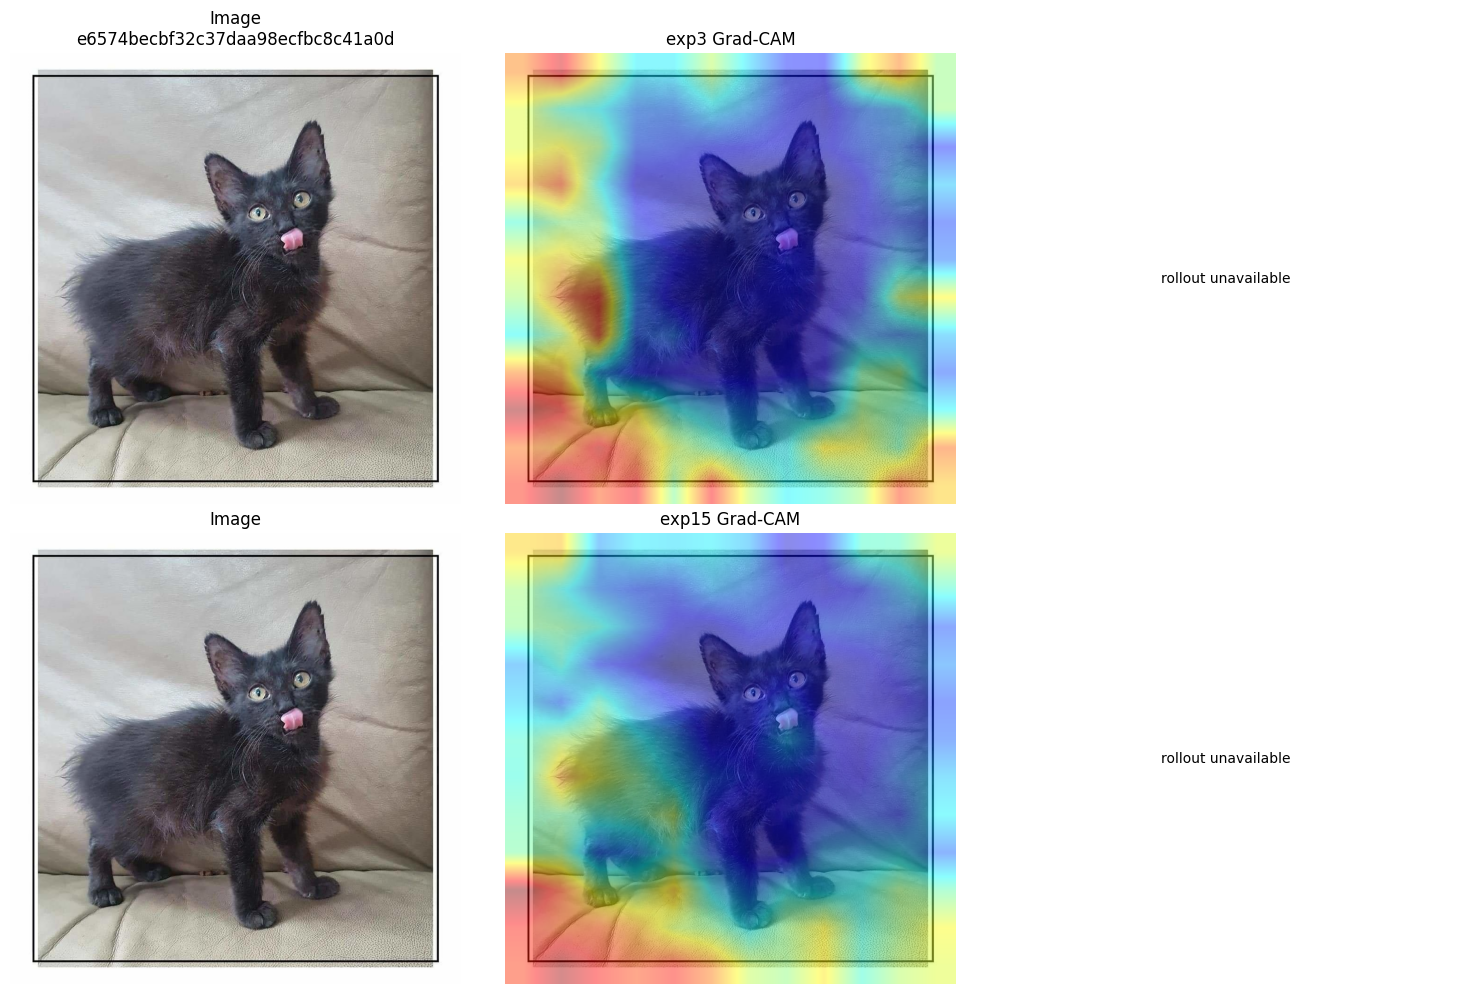

In [50]:
img_id = valid_df.sample(1, random_state=999).iloc[0]["Id"]
img_pil, row = get_image_and_row(img_id, valid_df)
rgb = np.array(img_pil.convert("RGB")).astype(np.float32) / 255.0

# Grad-CAM
cam3, _ = get_main_cam_exp3(img_pil, fold=FOLD)
cam15_main, _ = get_main_cam_exp15(img_pil, fold=FOLD)

# Rollout
rollout3 = None
rollout15 = None

try:
    rollout3 = get_attention_rollout_single(
        img_pil=img_pil,
        ckpt_path=os.path.join(EXP3_OUT, f"model_fold{FOLD}.pt"),
        backbone_name=cfg3["backbone"],
        img_size=cfg3["img_size"],
        aux_tasks=[],
    )
except Exception as e:
    print("exp3 rollout unavailable:", e)

try:
    rollout15 = get_attention_rollout_single(
        img_pil=img_pil,
        ckpt_path=os.path.join(EXP15_OUT, f"model_fold{FOLD}.pt"),
        backbone_name=cfg15["backbone"],
        img_size=cfg15["img_size"],
        aux_tasks=cfg15["aux_tasks"],
    )
except Exception as e:
    print("exp15 rollout unavailable:", e)

fig, axes = plt.subplots(2, 3, figsize=(15, 10))

axes[0, 0].imshow(rgb)
axes[0, 0].set_title(f"Image\n{img_id}")
axes[0, 0].axis("off")

axes[0, 1].imshow(overlay_cam_on_image(rgb, cam3))
axes[0, 1].set_title("exp3 Grad-CAM")
axes[0, 1].axis("off")

if rollout3 is not None:
    r3 = cv2.resize(rollout3.astype(np.float32), (img_pil.size[0], img_pil.size[1]))
    axes[0, 2].imshow(overlay_cam_on_image(rgb, r3))
    axes[0, 2].set_title("exp3 rollout")
else:
    axes[0, 2].text(0.5, 0.5, "rollout unavailable", ha="center", va="center")
    axes[0, 2].axis("off")

axes[1, 0].imshow(rgb)
axes[1, 0].set_title("Image")
axes[1, 0].axis("off")

axes[1, 1].imshow(overlay_cam_on_image(rgb, cam15_main))
axes[1, 1].set_title("exp15 Grad-CAM")
axes[1, 1].axis("off")

if rollout15 is not None:
    r15 = cv2.resize(rollout15.astype(np.float32), (img_pil.size[0], img_pil.size[1]))
    axes[1, 2].imshow(overlay_cam_on_image(rgb, r15))
    axes[1, 2].set_title("exp15 rollout")
else:
    axes[1, 2].text(0.5, 0.5, "rollout unavailable", ha="center", va="center")
    axes[1, 2].axis("off")

plt.tight_layout()
plt.show()